# Customer Lifetime Value (CLV) Prediction
### End-to-End ML Project in Google Colab

**Stack:** Pandas | Scikit-learn | XGBoost | Lifetimes | MLflow | FastAPI

**Dataset:** UCI Online Retail (free, auto-downloaded)

---
### Steps
1. Install Libraries
2. Load Dataset
3. Data Cleaning
4. Feature Engineering (RFM)
5. Statistical Model (BG/NBD + Gamma-Gamma)
6. ML Model (XGBoost)
7. Model Evaluation
8. MLflow Tracking
9. Customer Segmentation
10. Save Model + FastAPI Code

## STEP 1: Install and Import Libraries

In [ ]:
!pip install lifetimes mlflow fastapi uvicorn --quiet
print("All libraries installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 678.6 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix
import mlflow
import mlflow.sklearn
print("All imports successful!")

All imports successful!


## STEP 2: Load Dataset

In [ ]:
# Option A: Auto-download UCI Online Retail Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
print("Downloading dataset... (~30 seconds)")
df_raw = pd.read_excel(url)
print(f"Loaded! Shape: {df_raw.shape}")
df_raw.head()

Loaded! Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# Option B: Upload your own CSV (uncomment to use)
# from google.colab import files
# uploaded = files.upload()
# import io
# df_raw = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

print("Dataset Overview:")
print(f"  Rows      : {df_raw.shape[0]:,}")
print(f"  Columns   : {df_raw.shape[1]}")
print(f"  Customers : {df_raw['CustomerID'].nunique():,}")
print(f"  Countries : {df_raw['Country'].nunique()}")
print("\nMissing Values:")
print(df_raw.isnull().sum())

Dataset Overview:
  Rows      : 541,909
  Columns   : 8
  Customers : 4,372
  Countries : 38

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


## STEP 3: Data Cleaning

In [ ]:
df = df_raw.copy()

# Remove rows with no CustomerID
df.dropna(subset=["CustomerID"], inplace=True)

# Remove cancelled orders (start with C)
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove bad quantities and prices
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Create revenue column
df["TotalRevenue"] = df["Quantity"] * df["UnitPrice"]

# Parse dates
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Fix CustomerID type
df["CustomerID"] = df["CustomerID"].astype(int)

print(f"Cleaned shape: {df.shape}")
print(f"Customers: {df['CustomerID'].nunique():,}")
print(f"Date Range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
df.head()

Cleaned shape: (397884, 9)
Customers: 4,338
Date Range: 2010-12-01 to 2011-12-09


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalRevenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


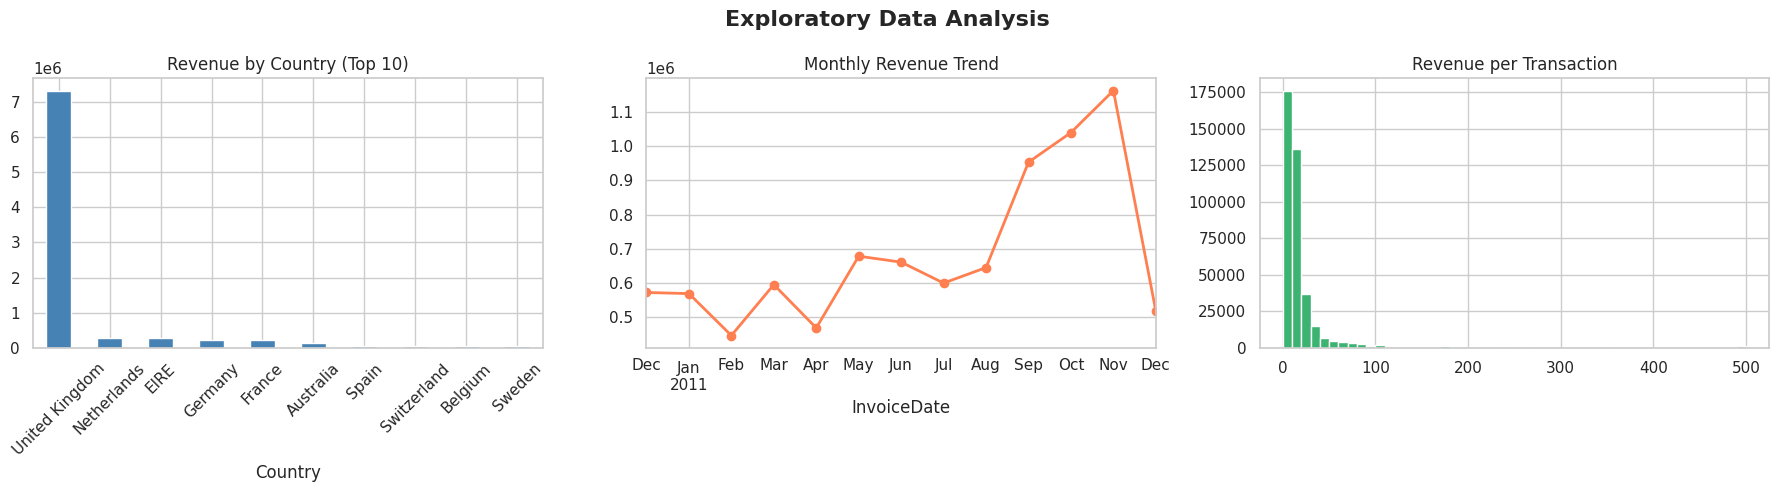

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Exploratory Data Analysis", fontsize=16, fontweight="bold")

top_countries = df.groupby("Country")["TotalRevenue"].sum().sort_values(ascending=False).head(10)
top_countries.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Revenue by Country (Top 10)")
axes[0].tick_params(axis="x", rotation=45)

monthly = df.groupby(df["InvoiceDate"].dt.to_period("M"))["TotalRevenue"].sum()
monthly.plot(kind="line", ax=axes[1], color="coral", marker="o", linewidth=2)
axes[1].set_title("Monthly Revenue Trend")

axes[2].hist(df["TotalRevenue"].clip(upper=500), bins=50, color="mediumseagreen", edgecolor="white")
axes[2].set_title("Revenue per Transaction")

plt.tight_layout()
plt.show()

## STEP 4: Feature Engineering (RFM + Extended Features)

In [ ]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Reference Date: {reference_date.date()}")

rfm = df.groupby("CustomerID").agg(
    LastPurchaseDate  = ("InvoiceDate", "max"),
    FirstPurchaseDate = ("InvoiceDate", "min"),
    Frequency         = ("InvoiceNo", "nunique"),
    Monetary          = ("TotalRevenue", "sum"),
    AvgOrderValue     = ("TotalRevenue", "mean"),
    TotalItems        = ("Quantity", "sum"),
    UniqueProducts    = ("StockCode", "nunique"),
).reset_index()

rfm["Recency"]     = (reference_date - rfm["LastPurchaseDate"]).dt.days
rfm["Tenure"]      = (reference_date - rfm["FirstPurchaseDate"]).dt.days
rfm["PurchaseGap"] = rfm["Tenure"] / rfm["Frequency"].replace(0, 1)
rfm["CLV"]         = rfm["Monetary"]
rfm.drop(columns=["LastPurchaseDate", "FirstPurchaseDate"], inplace=True)

print(f"RFM Table: {rfm.shape[0]:,} customers, {rfm.shape[1]-1} features")
rfm.head()

Reference Date: 2011-12-10
RFM Table: 4,338 customers, 9 features


,CustomerID,Frequency,Monetary,AvgOrderValue,TotalItems,UniqueProducts,Recency,Tenure,PurchaseGap,CLV
0,12346,1,77183.60,77183.600000,74215,1,326,326,326.000000,77183.60
1,12347,7,4310.00,23.681319,2458,103,2,367,52.428571,4310.00
2,12348,4,1797.24,57.975484,2341,22,75,358,89.500000,1797.24
3,12349,1,1757.55,24.076027,631,73,19,19,19.000000,1757.55
4,12350,1,334.40,19.670588,197,17,310,310,310.000000,334.40


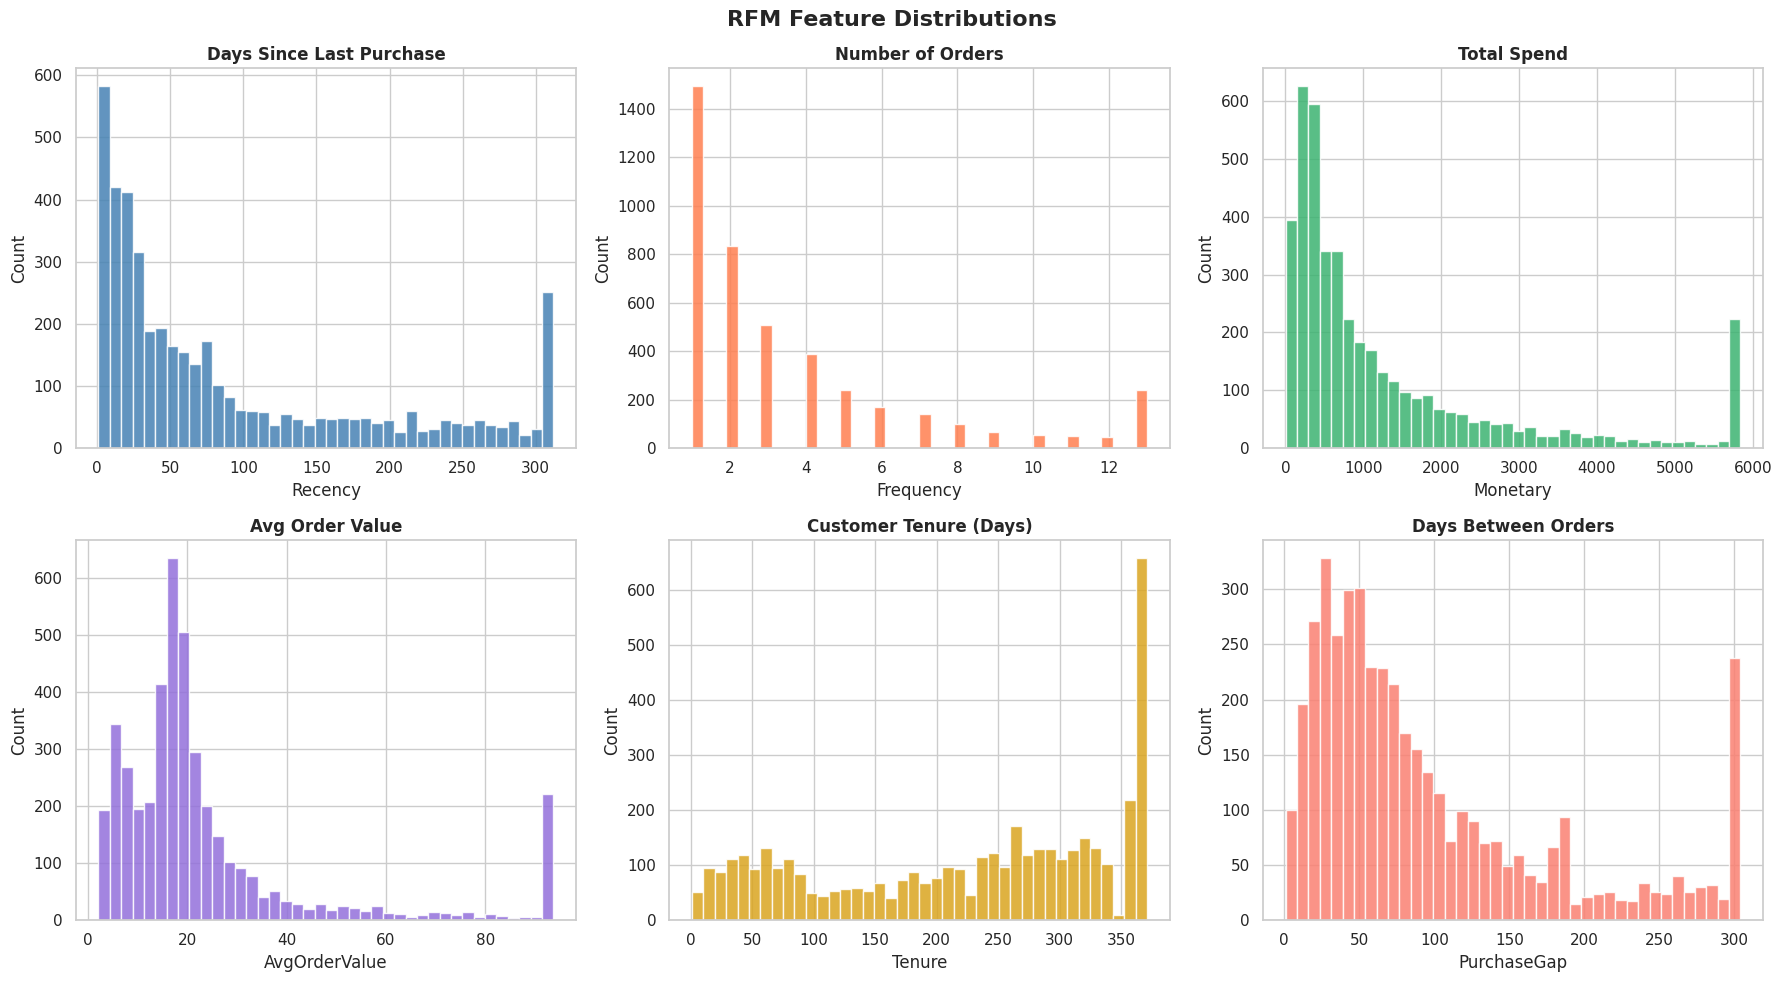

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("RFM Feature Distributions", fontsize=16, fontweight="bold")

features = [
    ("Recency",       "Days Since Last Purchase", "steelblue"),
    ("Frequency",     "Number of Orders",         "coral"),
    ("Monetary",      "Total Spend",              "mediumseagreen"),
    ("AvgOrderValue", "Avg Order Value",           "mediumpurple"),
    ("Tenure",        "Customer Tenure (Days)",   "goldenrod"),
    ("PurchaseGap",   "Days Between Orders",      "salmon"),
]

for ax, (col, label, color) in zip(axes.flat, features):
    data = rfm[col].clip(upper=rfm[col].quantile(0.95))
    ax.hist(data, bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## STEP 5: Statistical CLV Model (BG/NBD + Gamma-Gamma)

- **BG/NBD**: predicts future purchase frequency per customer
- **Gamma-Gamma**: predicts monetary value per purchase
- **Combined**: 12-month CLV forecast

In [ ]:
summary = summary_data_from_transaction_data(
    df,
    customer_id_col    = "CustomerID",
    datetime_col       = "InvoiceDate",
    monetary_value_col = "TotalRevenue",
    observation_period_end = reference_date
)
summary = summary[summary["frequency"] > 0]
print(f"Customers with repeat purchases: {len(summary):,}")
summary.head()

Customers with repeat purchases: 2,790


,frequency,recency,T,monetary_value
CustomerID,,,,
12347,6.0,365.0,368.0,599.701667
12348,3.0,283.0,359.0,301.480000
12352,6.0,260.0,297.0,368.256667
12356,2.0,303.0,326.0,269.905000
12358,1.0,149.0,151.0,683.200000


In [ ]:
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(summary["frequency"], summary["recency"], summary["T"])
print("BG/NBD Model fitted!")
print(bgf)

BG/NBD Model fitted!
<lifetimes.BetaGeoFitter: fitted with 2790 subjects, a: 0.01, alpha: 90.34, b: 0.14, r: 1.60>


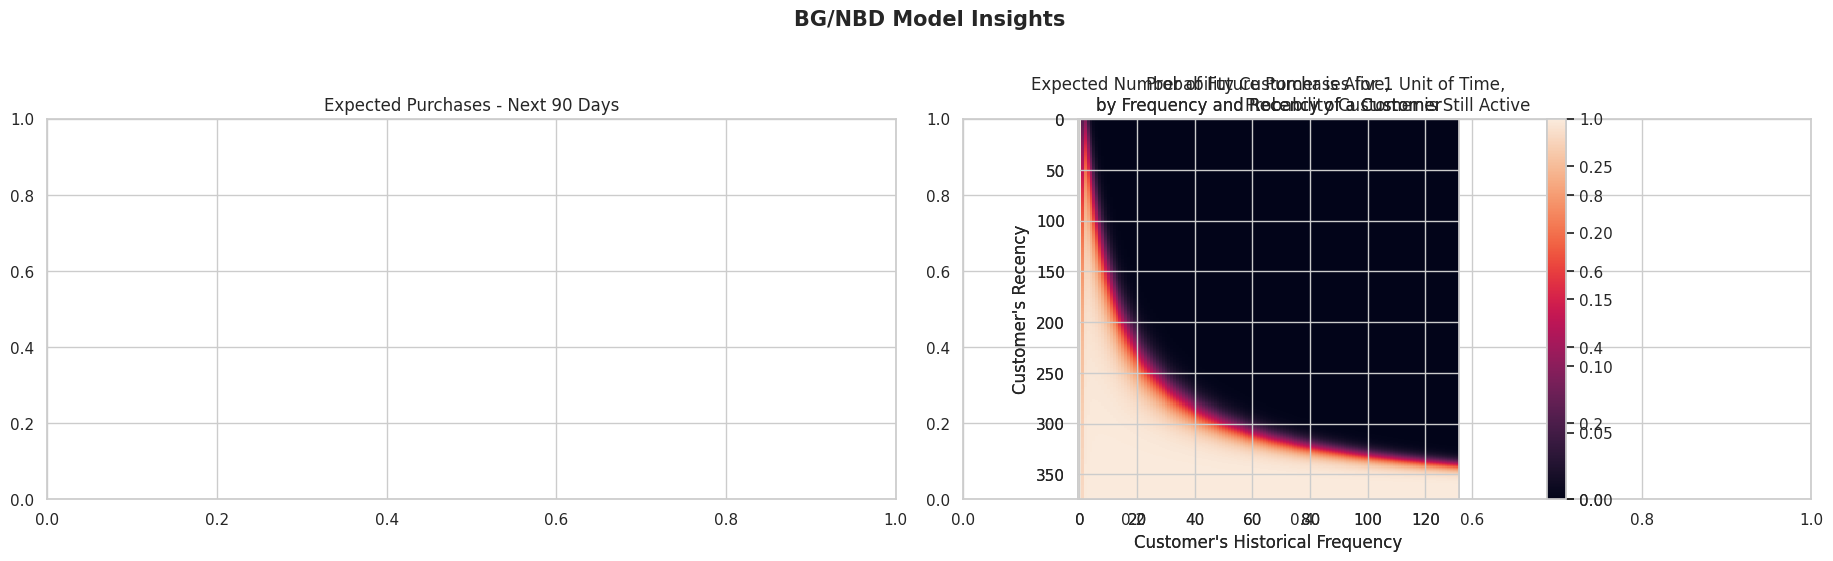

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("BG/NBD Model Insights", fontsize=15, fontweight="bold")

# Plot on the first axes
plt.sca(axes[0])
plot_frequency_recency_matrix(bgf)
axes[0].set_title("Expected Purchases - Next 90 Days")

# Plot on the second axes
plt.sca(axes[1])
plot_probability_alive_matrix(bgf)
axes[1].set_title("Probability Customer is Still Active")

plt.tight_layout()
plt.show()

In [ ]:
returning = summary[summary["monetary_value"] > 0]
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(returning["frequency"], returning["monetary_value"])
print("Gamma-Gamma Model fitted!")
print(ggf)

Gamma-Gamma Model fitted!
<lifetimes.GammaGammaFitter: fitted with 2790 subjects, p: 3.75, q: 0.33, v: 3.64>


In [ ]:
clv_predictions = ggf.customer_lifetime_value(
    bgf,
    returning["frequency"],
    returning["recency"],
    returning["T"],
    returning["monetary_value"],
    time=12,
    discount_rate=0.01
)

clv_df = pd.DataFrame({
    "CustomerID"    : clv_predictions.index,
    "Predicted_CLV" : clv_predictions.values
})

print(f"CLV predicted for {len(clv_df):,} customers")
print(clv_df["Predicted_CLV"].describe().round(2))

CLV predicted for 2,790 customers
count      2790.00
mean       3080.14
std       13687.29
min          12.50
25%         783.77
50%        1513.35
75%        2836.41
max      574087.72
Name: Predicted_CLV, dtype: float64


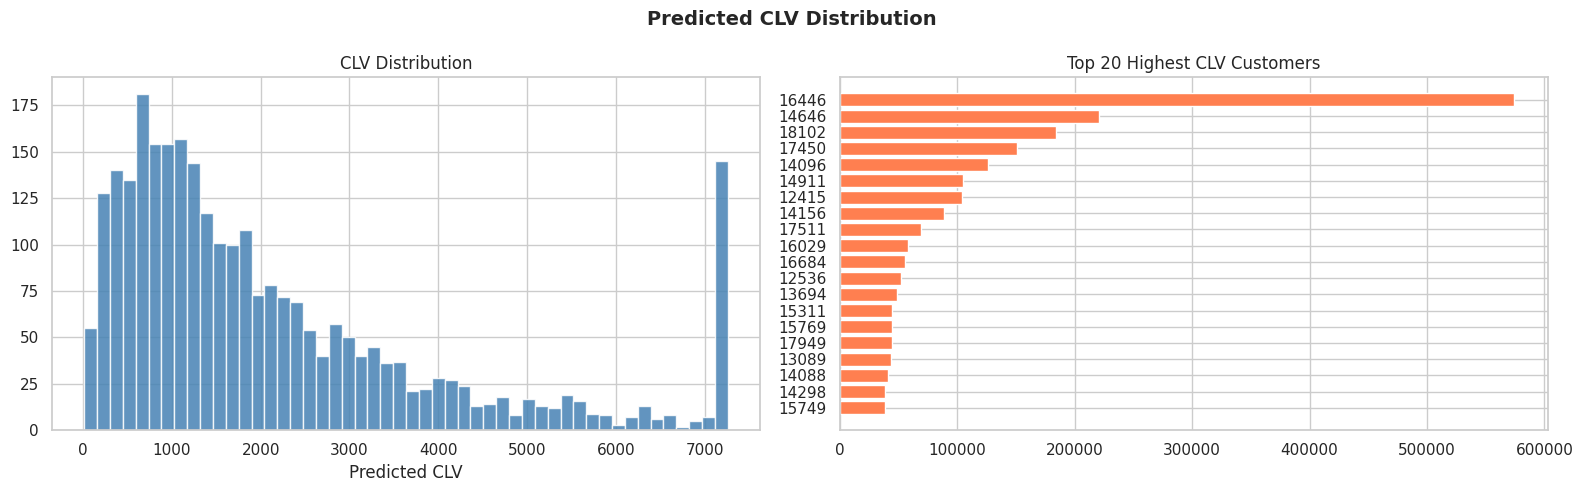

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Predicted CLV Distribution", fontsize=14, fontweight="bold")

clipped = clv_df["Predicted_CLV"].clip(upper=clv_df["Predicted_CLV"].quantile(0.95))
axes[0].hist(clipped, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_title("CLV Distribution")
axes[0].set_xlabel("Predicted CLV")

top20 = clv_df.nlargest(20, "Predicted_CLV")
axes[1].barh(top20["CustomerID"].astype(str), top20["Predicted_CLV"], color="coral")
axes[1].set_title("Top 20 Highest CLV Customers")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## STEP 6: ML Model (XGBoost)

In [ ]:
feature_cols = [
    "Recency", "Frequency", "AvgOrderValue",
    "TotalItems", "UniqueProducts", "Tenure", "PurchaseGap"
]

X = rfm[feature_cols]
y = np.log1p(rfm["CLV"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,} | Features: {len(feature_cols)}")

Train: 3,470 | Test: 868 | Features: 7


In [ ]:
xgb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  XGBRegressor(
        n_estimators=300, max_depth=6,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, random_state=42, verbosity=0
    ))
])

print("Training XGBoost...")
xgb_pipeline.fit(X_train, y_train)
print("Training complete!")

Training XGBoost...
Training complete!


## STEP 7: Model Evaluation

In [ ]:
y_pred = np.expm1(xgb_pipeline.predict(X_test))
y_true = np.expm1(y_test)

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

print("=" * 45)
print("     MODEL EVALUATION RESULTS")
print("=" * 45)
print(f"  MAE  (Mean Absolute Error) : {mae:>10.2f}")
print(f"  RMSE (Root Mean Sq Error)  : {rmse:>10.2f}")
print(f"  R2   (Explained Variance)  :  {r2:>10.4f}")
print("=" * 45)
rating = "Great model!" if r2 > 0.7 else "Decent - consider more tuning"
print(f"  Verdict: {rating}")

     MODEL EVALUATION RESULTS
  MAE  (Mean Absolute Error) :     555.58
  RMSE (Root Mean Sq Error)  :    4634.95
  R2   (Explained Variance)  :      0.7903
  Verdict: Great model!


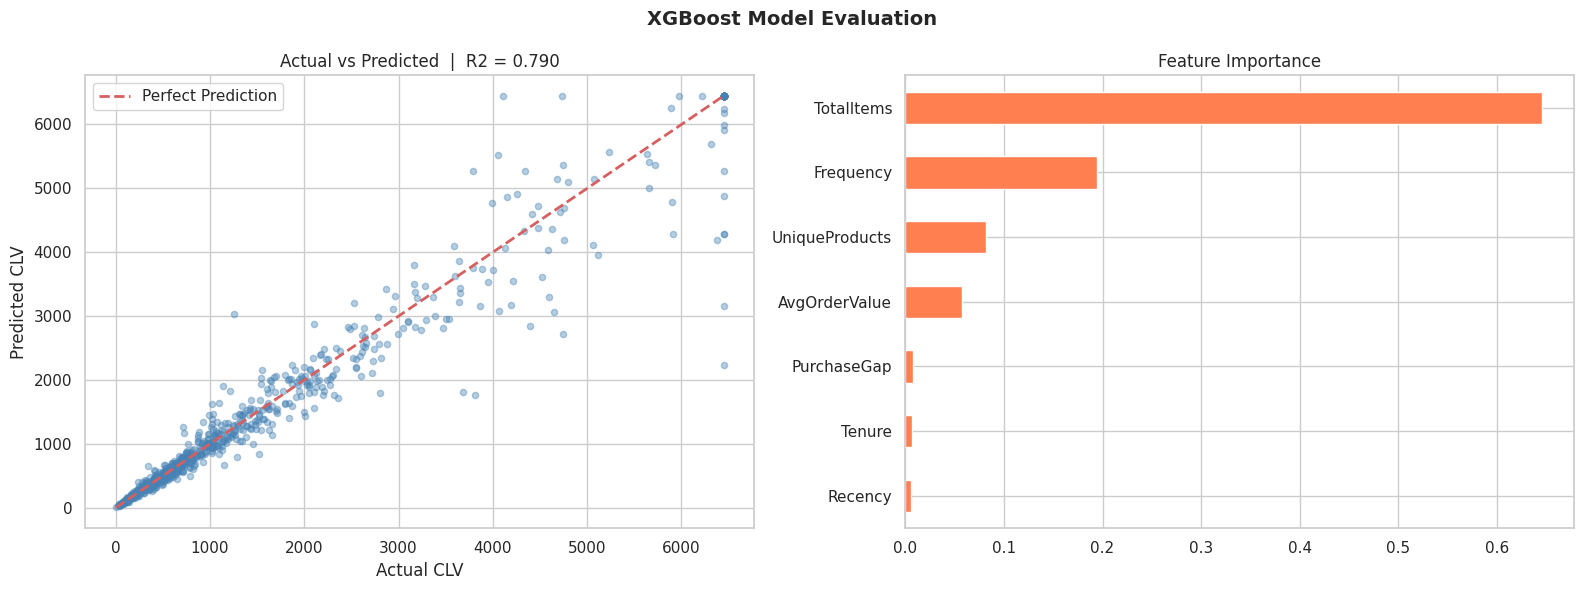

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("XGBoost Model Evaluation", fontsize=14, fontweight="bold")

clip_val = float(np.percentile(y_true, 95))
axes[0].scatter(
    y_true.clip(upper=clip_val),
    np.clip(y_pred, 0, clip_val),
    alpha=0.4, color="steelblue", s=20
)
axes[0].plot([0, clip_val], [0, clip_val], "r--", lw=2, label="Perfect Prediction")
axes[0].set_xlabel("Actual CLV")
axes[0].set_ylabel("Predicted CLV")
axes[0].set_title(f"Actual vs Predicted  |  R2 = {r2:.3f}")
axes[0].legend()

xgb_model   = xgb_pipeline.named_steps["model"]
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind="barh", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Feature Importance")

plt.tight_layout()
plt.show()

## STEP 8: MLflow Experiment Tracking

In [ ]:
mlflow.set_experiment("CLV_Prediction")

with mlflow.start_run(run_name="XGBoost_CLV_v1"):
    mlflow.log_params({
        "model": "XGBoost", "n_estimators": 300,
        "max_depth": 6, "learning_rate": 0.05,
        "train_size": len(X_train), "test_size": len(X_test),
    })
    mlflow.log_metrics({
        "MAE": round(mae, 4), "RMSE": round(rmse, 4), "R2": round(r2, 4)
    })
    mlflow.sklearn.log_model(xgb_pipeline, "clv_model")
    run_id = mlflow.active_run().info.run_id

print(f"MLflow run logged! Run ID: {run_id}")
print(f"  MAE : {mae:.2f}")
print(f"  RMSE: {rmse:.2f}")
print(f"  R2  : {r2:.4f}")

2026/05/10 10:04:58 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/10 10:04:58 INFO mlflow.store.db.utils: Updating database tables
2026/05/10 10:05:00 INFO mlflow.tracking.fluent: Experiment with name 'CLV_Prediction' does not exist. Creating a new experiment.
2026/05/10 10:05:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/10 10:05:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run logged! Run ID: 8531bc068663487b86e6af0f7a086214
  MAE : 555.58
  RMSE: 4634.95
  R2  : 0.7903


## STEP 9: Customer Segmentation by CLV Tier

In [ ]:
rfm["Predicted_CLV"] = np.expm1(xgb_pipeline.predict(rfm[feature_cols]))

p25 = rfm["Predicted_CLV"].quantile(0.25)
p50 = rfm["Predicted_CLV"].quantile(0.50)
p75 = rfm["Predicted_CLV"].quantile(0.75)

def assign_tier(clv):
    if   clv >= p75: return "Platinum"
    elif clv >= p50: return "Gold"
    elif clv >= p25: return "Silver"
    else:            return "Bronze"

rfm["CLV_Tier"] = rfm["Predicted_CLV"].apply(assign_tier)

tier_summary = rfm.groupby("CLV_Tier").agg(
    CustomerCount = ("CustomerID", "count"),
    Avg_CLV       = ("Predicted_CLV", "mean"),
    Total_Revenue = ("Predicted_CLV", "sum"),
    Avg_Frequency = ("Frequency", "mean"),
).round(2)

print("Customer Tier Summary:")
print(tier_summary.to_string())

Customer Tier Summary:
          CustomerCount      Avg_CLV  Total_Revenue  Avg_Frequency
CLV_Tier                                                          
Bronze             1085   180.619995   1.959710e+05           1.25
Gold               1084  1071.640015   1.161660e+06           3.47
Platinum           1085  6362.390137   6.903194e+06          10.47
Silver             1084   464.309998   5.033083e+05           1.89


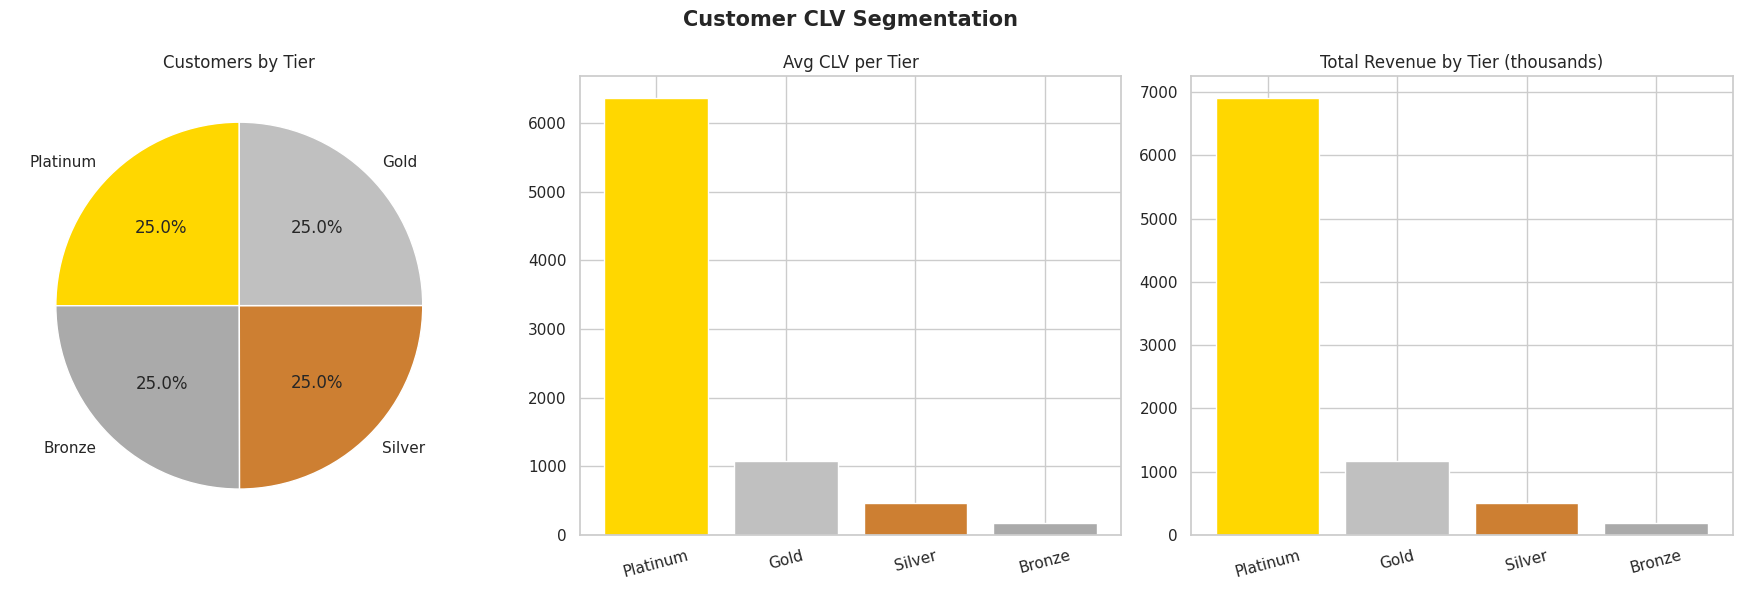

In [ ]:
tier_colors = {
    "Platinum": "#FFD700",
    "Gold"    : "#C0C0C0",
    "Silver"  : "#CD7F32",
    "Bronze"  : "#AAAAAA"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Customer CLV Segmentation", fontsize=15, fontweight="bold")

counts  = rfm["CLV_Tier"].value_counts()
colors  = [tier_colors.get(t, "gray") for t in counts.index]
axes[0].pie(counts.values, labels=counts.index, autopct="%1.1f%%", colors=colors, startangle=90)
axes[0].set_title("Customers by Tier")

avg_clv = rfm.groupby("CLV_Tier")["Predicted_CLV"].mean().sort_values(ascending=False)
bar_c   = [tier_colors.get(t, "gray") for t in avg_clv.index]
axes[1].bar(avg_clv.index, avg_clv.values, color=bar_c, edgecolor="white")
axes[1].set_title("Avg CLV per Tier")
axes[1].tick_params(axis="x", rotation=15)

total_rev = rfm.groupby("CLV_Tier")["Predicted_CLV"].sum().sort_values(ascending=False)
axes[2].bar(total_rev.index, total_rev.values / 1000,
            color=[tier_colors.get(t, "gray") for t in total_rev.index], edgecolor="white")
axes[2].set_title("Total Revenue by Tier (thousands)")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## STEP 10: Save Model and Export Predictions

In [ ]:
# Save model
joblib.dump(xgb_pipeline, "clv_model.pkl")
print("Model saved: clv_model.pkl")

# Export predictions
output = rfm[["CustomerID","Recency","Frequency","Monetary",
              "Tenure","Predicted_CLV","CLV_Tier"]].copy()
output.to_csv("clv_predictions.csv", index=False)
print("Predictions saved: clv_predictions.csv")

# Download in Colab
try:
    from google.colab import files
    files.download("clv_model.pkl")
    files.download("clv_predictions.csv")
    print("Files downloaded!")
except Exception:
    print("Files saved in current directory.")

print("\nTop 10 Customers by Predicted CLV:")
output.nlargest(10, "Predicted_CLV")[["CustomerID","Frequency","Monetary","Predicted_CLV","CLV_Tier"]]

Model saved: clv_model.pkl
Predictions saved: clv_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files downloaded!

Top 10 Customers by Predicted CLV:


,CustomerID,Frequency,Monetary,Predicted_CLV,CLV_Tier
1689,14646,73,280206.02,265566.406250,Platinum
3728,17450,46,194550.79,181179.375000,Platinum
3008,16446,2,168472.50,159748.968750,Platinum
4201,18102,60,259657.30,146794.015625,Platinum
1879,14911,201,143825.06,130280.085938,Platinum
55,12415,21,124914.53,130167.070312,Platinum
1333,14156,55,117379.63,118195.671875,Platinum
2176,15311,91,60767.90,111413.171875,Platinum
3771,17511,31,91062.38,88782.765625,Platinum
2702,16029,63,81024.84,76307.484375,Platinum


## FastAPI Deployment Code

Copy this into `app.py`, push to GitHub, and deploy FREE on Render.com

**Deploy Steps:**
1. Push `app.py` + `clv_model.pkl` + `requirements.txt` to GitHub
2. Connect repo to Render.com (free)
3. Start command: `uvicorn app:app --host 0.0.0.0 --port 10000`
4. Your API is live at `https://your-app.onrender.com/docs`

In [ ]:
app_code = """
from fastapi import FastAPI
from pydantic import BaseModel
import joblib, numpy as np, pandas as pd

model = joblib.load("clv_model.pkl")
app   = FastAPI(title="CLV Prediction API", version="1.0.0")

class CustomerData(BaseModel):
    Recency: float
    Frequency: float
    AvgOrderValue: float
    TotalItems: float
    UniqueProducts: float
    Tenure: float
    PurchaseGap: float

def assign_tier(clv):
    if clv >= 5000: return "Platinum"
    elif clv >= 1000: return "Gold"
    elif clv >= 300: return "Silver"
    return "Bronze"

@app.get("/")
def root():
    return {"message": "CLV API is running! Visit /docs for Swagger UI"}

@app.post("/predict")
def predict(customer: CustomerData):
    features = pd.DataFrame([customer.dict()])
    log_clv  = model.predict(features)[0]
    clv      = round(float(np.expm1(log_clv)), 2)
    return {"predicted_clv_12months": clv, "currency": "GBP",
            "tier": assign_tier(clv)}

@app.get("/health")
def health():
    return {"status": "healthy"}
"""

with open("app.py", "w") as f:
    f.write(app_code)

reqs = "fastapi\nuvicorn\njoblib\nnumpy\npandas\nxgboost\nscikit-learn\n"
with open("requirements.txt", "w") as f:
    f.write(reqs)

print("app.py created!")
print("requirements.txt created!")
print("\nrequirements.txt contents:")
print(reqs)

app.py created!
requirements.txt created!

requirements.txt contents:
fastapi
uvicorn
joblib
numpy
pandas
xgboost
scikit-learn



In [ ]:
# Quick in-notebook prediction test
test_input = {
    "Recency": 30, "Frequency": 12, "AvgOrderValue": 85.5,
    "TotalItems": 200, "UniqueProducts": 45,
    "Tenure": 365, "PurchaseGap": 30.4
}

features = pd.DataFrame([test_input])
log_clv  = xgb_pipeline.predict(features)[0]
clv_val  = round(float(np.expm1(log_clv)), 2)

def tier(clv):
    if clv >= 5000: return "Platinum"
    elif clv >= 1000: return "Gold"
    elif clv >= 300: return "Silver"
    return "Bronze"

print("Test Prediction:")
print(f"  Frequency=12 | AOV=85.5 | Tenure=365 days")
print(f"  Predicted CLV : {clv_val:,.2f}")
print(f"  Customer Tier : {tier(clv_val)}")

Test Prediction:
  Frequency=12 | AOV=85.5 | Tenure=365 days
  Predicted CLV : 3,146.29
  Customer Tier : Gold


## Project Complete!

---

### What You Built

| Component | Status |
|---|---|
| Data Cleaning and EDA | Done |
| RFM Feature Engineering | Done |
| BG/NBD + Gamma-Gamma Model | Done |
| XGBoost ML Pipeline | Done |
| Evaluation (MAE, RMSE, R2) | Done |
| MLflow Experiment Tracking | Done |
| Customer Tier Segmentation | Done |
| Model Export (.pkl) | Done |
| CSV Predictions Export | Done |
| FastAPI Deployment Code | Done |

---

### Next Steps
1. Import `clv_predictions.csv` into Power BI for a business dashboard
2. Deploy `app.py` + `clv_model.pkl` to Render.com from GitHub
3. Schedule monthly retraining as new data arrives
4. Run A/B campaigns on Platinum vs Bronze tiers and measure ROI